# Glucose-only SDE inference: EnKF + NUTS versus EnKF + Metropolis–Hastings

This notebook **defines the model, generates new synthetic SDE data, and runs both samplers**. It does not load the earlier experiment's samples or import its model code.

We use the existing Dynestyx `DynamicalModel`, `SDESimulator`, `Discretizer`, and `Filter` APIs. NUTS uses NumPyro; MH uses Dynestyx's `MCMCInference(AdaptiveMetropolisConfig(...))`. The latter is adaptive **coordinatewise random-walk Metropolis-within-Gibbs**, not a joint Gaussian proposal. Adaptation stops after warmup.

Both samplers fit only insulin sensitivity $S$ and secretion $B$. The **20-member EnKF** integrates out the initial state and latent trajectory. Its random key is fixed for both algorithms, so they target the same repeatable, approximate EnKF posterior.

The drift is an illustrative oral-challenge model, not a calibrated clinical oral minimal model:

$$\begin{aligned}
dG &= [0.035Q-0.015(G-5)-SJG]dt+0.025\,dW_G,\\
dJ &= [B(G-5)-0.08J]dt+0.12\,dW_J,\\
dQ &= -0.035Q\,dt.
\end{aligned}$$

Time is in minutes; $G$ is glucose in mmol/L; $J$ is an insulin excursion around basal insulin in illustrative units; $Q$ is an effective gut glucose load in mmol/L. All other constants and diffusion amplitudes are known. Glucose alone is observed. In the ODE limit with $J(0)=0$, glucose depends on the product $SB$, producing a hyperbolic sensitivity–secretion ridge. Fixed insulin noise weakly breaks that exact symmetry.

For established physiological modeling and required measurements, see [The Oral Minimal Model Method](https://pmc.ncbi.nlm.nih.gov/articles/PMC4179313/).

In [1]:
import json
import time
from importlib.metadata import version
from pathlib import Path

import jax

jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import pandas as pd
from IPython.display import display
from numpyro.diagnostics import autocorrelation, summary
from numpyro.infer import MCMC, NUTS, Predictive, init_to_median
from numpyro.infer.util import log_density
from scipy.special import logsumexp

import dynestyx as dsx
from dynestyx.inference.configs.discretizer import EulerMaruyamaConfig
from dynestyx.inference.configs.filter import EnKFConfig
from dynestyx.inference.configs.mcmc import AdaptiveMetropolisConfig
from dynestyx.inference.mcmc import MCMCInference

root = Path.cwd().resolve()
while not (root / "dynestyx").is_dir():
    if root == root.parent:
        raise RuntimeError("Run this notebook from the Dynestyx repository.")
    root = root.parent
OUT = root / "examples/ogtt_sde/results/sampler_comparison"
OUT.mkdir(parents=True, exist_ok=True)

TRUE = {"sensitivity": 0.001, "secretion": 0.8}
NAMES = tuple(TRUE)
INITIAL = jnp.array([5.0, 0.0, 10.0])
INITIAL_SD = jnp.array([0.15, 0.1, 0.3])
DIFFUSION = jnp.array([[0.025, 0.0], [0.0, 0.12], [0.0, 0.0]])
OBS_TIMES = jnp.array([0.0, 15.0, 30.0, 45.0, 60.0, 90.0, 120.0, 180.0])
OBS_SD = 0.25
ENSEMBLE = 20
FILTER_DT = 0.5
SIM_DT = 0.025
NUM_CHAINS = 2
# Different budgets are intentional: random-walk MH has greater autocorrelation.
NUTS_WARMUP, NUTS_SAMPLES = 200, 800
MH_WARMUP, MH_SAMPLES = 1500, 10000
INIT = init_to_median(num_samples=15)
VERSIONS = {
    k: version(k) for k in ["dynestyx", "jax", "numpyro", "blackjax", "cuthbert"]
}
print(VERSIONS)
print("Device:", jax.devices())

{'dynestyx': '0.6.0', 'jax': '0.11.2', 'numpyro': '0.22.0', 'blackjax': '1.6.2', 'cuthbert': '0.1.0'}
Device: [CpuDevice(id=0)]


## Define the model

The initial state has independent Normal uncertainty with mean $(5,0,10)$ and SD $(0.15,0.1,0.3)$. Both positive parameters have LogNormal priors centered in log space on their synthetic truth, with log SD 0.7. An insulin excursion can be negative when insulin falls below its basal level.

In [2]:
def dynamics(sensitivity, secretion):
    def drift(z, u, t):
        g, insulin, gut = z
        return jnp.array(
            [
                0.035 * gut - 0.015 * (g - 5.0) - sensitivity * insulin * g,
                secretion * (g - 5.0) - 0.08 * insulin,
                -0.035 * gut,
            ]
        )

    return dsx.DynamicalModel(
        initial_condition=dist.MultivariateNormal(INITIAL, jnp.diag(INITIAL_SD**2)),
        state_evolution=dsx.ContinuousTimeStateEvolution(
            drift=drift, diffusion=dsx.FullDiffusion(DIFFUSION)
        ),
        observation_model=dsx.LinearGaussianObservation(
            H=jnp.array([[1.0, 0.0, 0.0]]), R=jnp.array([[OBS_SD**2]])
        ),
    )


def model(
    obs_times=None,
    obs_values=None,
    ctrl_times=None,
    ctrl_values=None,
    predict_times=None,
):
    s = numpyro.sample("sensitivity", dist.LogNormal(jnp.log(TRUE["sensitivity"]), 0.7))
    b = numpyro.sample("secretion", dist.LogNormal(jnp.log(TRUE["secretion"]), 0.7))
    return dsx.sample(
        "ogtt",
        dynamics(s, b),
        obs_times=obs_times,
        obs_values=obs_values,
        predict_times=predict_times,
        ctrl_times=ctrl_times,
        ctrl_values=ctrl_values,
    )

## Simulate the SDE and noisy glucose observations

Use Dynestyx's existing Euler–Maruyama simulation backend with a smaller timestep than the filter. Retain eight glucose measurements; the dense true state path is used only for visualizing synthetic truth.

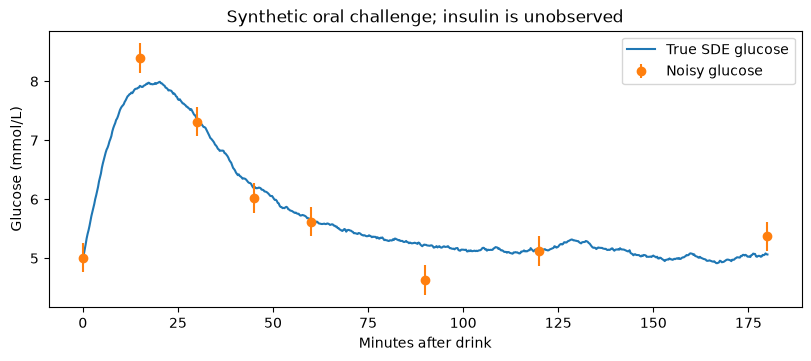

In [3]:
display_times = jnp.arange(721) * 0.25
with dsx.SDESimulator(dsx.SDESimulatorConfig(dt0=SIM_DT)):
    generated = Predictive(
        model, params={k: jnp.array(v) for k, v in TRUE.items()}, num_samples=1
    )(jr.PRNGKey(12), predict_times=display_times)
true_states = generated["ogtt_states"][0, 0]
indices = np.rint(np.asarray(OBS_TIMES) / 0.25).astype(int)
y = generated["ogtt_observations"][0, 0, indices]
np.savez_compressed(
    OUT / "data.npz",
    times=display_times,
    states=true_states,
    observation_times=OBS_TIMES,
    observations=y,
)

fig, ax = plt.subplots(figsize=(8, 3.5), constrained_layout=True)
ax.plot(display_times, true_states[:, 0], label="True SDE glucose")
ax.errorbar(OBS_TIMES, y[:, 0], yerr=OBS_SD, fmt="o", label="Noisy glucose")
ax.set(
    xlabel="Minutes after drink",
    ylabel="Glucose (mmol/L)",
    title="Synthetic oral challenge; insulin is unobserved",
)
ax.legend()
plt.show()

## The shared EnKF marginal likelihood

Missing measurements on the fine integration grid are NaNs, not interpolated observations. `Discretizer` supplies the existing Euler–Maruyama transition and `Filter` adds its marginal likelihood to the NumPyro model. Negligible covariance jitter enables Cholesky for rank-two diffusion in three states.

**The fixed `crn_seed` is essential:** both samplers target the same deterministic finite-ensemble likelihood. This is approximate EnKF inference, not exact pseudo-marginal MH. Neither sampler has latent-state or initial-condition coordinates.

In [4]:
fine_indices = np.rint(np.asarray(OBS_TIMES) / FILTER_DT).astype(int)
assert np.allclose(fine_indices * FILTER_DT, OBS_TIMES)
fine_times = jnp.arange(fine_indices[-1] + 1) * FILTER_DT
fine_y = jnp.full((len(fine_times), 1), jnp.nan).at[fine_indices].set(y)


def filter_config():
    return EnKFConfig(
        n_particles=ENSEMBLE,
        crn_seed=jr.PRNGKey(0),
        warn=False,
        record_filtered_states_mean=False,
        record_filtered_states_cov=False,
        record_filtered_particles=False,
        include_predicted_observations=False,
        record_predicted_observations_mean=False,
        record_predicted_observations_cov=False,
        record_predicted_observations_ensemble=False,
    )


def discretizer():
    return dsx.Discretizer(EulerMaruyamaConfig(covariance_jitter=1e-12))


with dsx.Filter(filter_config()), discretizer():
    trace = numpyro.handlers.trace(numpyro.handlers.seed(model, 0)).get_trace(
        obs_times=fine_times, obs_values=fine_y
    )
    target_values = [
        log_density(
            numpyro.handlers.seed(model, seed),
            (),
            {"obs_times": fine_times, "obs_values": fine_y},
            TRUE,
        )[0]
        for seed in (0, 123)
    ]
sites = [k for k, v in trace.items() if v["type"] == "sample" and not v["is_observed"]]
assert set(sites) == set(NAMES), sites
np.testing.assert_allclose(target_values[0], target_values[1], atol=1e-12, rtol=0)
print("Unobserved sampler sites:", sites)
print("Same log target under different outer sampler keys:", np.asarray(target_values))


def evaluate_likelihood(theta):
    filt = dsx.Filter(filter_config())
    with filt, discretizer():
        numpyro.handlers.substitute(model, data=dict(zip(NAMES, theta, strict=True)))(
            obs_times=fine_times, obs_values=fine_y
        )
    return filt.marginal_loglik


loglik = jax.jit(evaluate_likelihood)

Unobserved sampler sites: ['sensitivity', 'secretion']
Same log target under different outer sampler keys: [4.66456261 4.66456261]


## (a) EnKF + NUTS

Use dense mass adaptation and forward-mode differentiation for two parameters. Chains run sequentially. The timer includes sampler construction, JIT compilation, warmup, and retained draws, and stops only after JAX results are ready. Initialization is NumPyro's prior-median strategy with independent random keys.

In [5]:
start = time.perf_counter()
with dsx.Filter(filter_config()), discretizer():
    nuts = MCMC(
        NUTS(
            model,
            dense_mass=True,
            target_accept_prob=0.9,
            forward_mode_differentiation=True,
            init_strategy=INIT,
        ),
        num_warmup=NUTS_WARMUP,
        num_samples=NUTS_SAMPLES,
        num_chains=NUM_CHAINS,
        chain_method="sequential",
        progress_bar=False,
    )
    nuts.run(
        jr.PRNGKey(42),
        obs_times=fine_times,
        obs_values=fine_y,
        extra_fields=("diverging", "accept_prob", "num_steps"),
    )
    nuts_samples = {k: nuts.get_samples(group_by_chain=True)[k] for k in NAMES}
    nuts_extra = nuts.get_extra_fields(group_by_chain=True)
    jax.block_until_ready((nuts_samples, nuts_extra))
nuts_seconds = time.perf_counter() - start
nuts_samples = {k: np.asarray(v) for k, v in nuts_samples.items()}
nuts_diagnostics = {
    "mean_acceptance_rate": np.asarray(nuts_extra["accept_prob"]).mean(axis=1).tolist(),
    "num_divergences": np.asarray(nuts_extra["diverging"]).sum(axis=1).tolist(),
    "mean_num_steps": np.asarray(nuts_extra["num_steps"]).mean(axis=1).tolist(),
}
np.savez_compressed(OUT / "nuts_samples.npz", **nuts_samples)
(OUT / "nuts_run.json").write_text(
    json.dumps({"seconds": nuts_seconds, **nuts_diagnostics}, indent=2)
)
print(f"NUTS: {nuts_seconds:.2f} seconds")
display(
    pd.DataFrame(nuts_diagnostics, index=[f"chain {i + 1}" for i in range(NUM_CHAINS)])
)

NUTS: 86.45 seconds


,mean_acceptance_rate,num_divergences,mean_num_steps
chain 1,0.919496,0,3.7575
chain 2,0.943529,0,4.6375


## (b) EnKF + Dynestyx adaptive Metropolis–Hastings

One MH iteration sweeps both unconstrained coordinates with Gaussian proposals. This needs no likelihood gradient. Proposal scales adapt only during warmup. The initial scale 0.3 is in NumPyro's unconstrained (log-positive) coordinates; reported samples and plots remain in physical coefficient units.

Use more retained MH iterations because coordinatewise random walks can move slowly along a narrow correlated ridge. We retain every draw without thinning. BlackJAX batches the two chains on the available device; that execution choice is part of this end-to-end implementation comparison.

In [6]:
start = time.perf_counter()
with dsx.Filter(filter_config()), discretizer():
    mh = MCMCInference(
        AdaptiveMetropolisConfig(
            num_warmup=MH_WARMUP,
            num_samples=MH_SAMPLES,
            num_chains=NUM_CHAINS,
            initial_proposal_scale=0.3,
            target_acceptance_rate=0.44,
            max_adaptation=0.01,
            init_strategy=INIT,
        ),
        model,
    )
    mh_raw = mh.run(jr.PRNGKey(43), fine_times, fine_y)
    mh_diagnostics_raw = mh.get_diagnostics()
    jax.block_until_ready((mh_raw, mh_diagnostics_raw))
mh_seconds = time.perf_counter() - start
mh_samples = {k: np.asarray(mh_raw[k]) for k in NAMES}
assert all(v.shape == (NUM_CHAINS, MH_SAMPLES) for v in mh_samples.values())
mh_diagnostics = {k: np.asarray(v).tolist() for k, v in mh_diagnostics_raw.items()}
np.savez_compressed(OUT / "mh_samples.npz", **mh_samples)
(OUT / "mh_run.json").write_text(
    json.dumps({"seconds": mh_seconds, **mh_diagnostics}, indent=2)
)
# BlackJAX flattens the latent dict in sorted-name order.
coordinate_names = sorted(NAMES)
acceptance = pd.DataFrame(
    np.asarray(mh_diagnostics_raw["mean_acceptance_rate"]),
    columns=coordinate_names,
    index=[f"chain {i + 1}" for i in range(NUM_CHAINS)],
)
scales = pd.DataFrame(
    np.asarray(mh_diagnostics_raw["final_proposal_scale"]),
    columns=coordinate_names,
    index=acceptance.index,
)
print(f"MH: {mh_seconds:.2f} seconds")
print("Post-warmup acceptance rates per coordinate:")
display(acceptance)
print("Final frozen proposal scales in unconstrained coordinates:")
display(scales)

MH: 129.36 seconds
Post-warmup acceptance rates per coordinate:


,secretion,sensitivity
chain 1,0.5725,0.6273
chain 2,0.3911,0.3357


Final frozen proposal scales in unconstrained coordinates:


,secretion,sensitivity
chain 1,0.151985,0.126949
chain 2,0.276935,0.331551


## MCMC diagnostics and ESS per second

We use the **same NumPyro diagnostic implementation** for both methods: effective sample size (`n_eff`) and split R-hat (`r_hat`). These are conventional diagnostics, not rank-normalized bulk/tail ESS. Include the derived sensitivity × secretion product because it is the quantity glucose primarily constrains.

`ESS/second = combined-chain ESS / measured wall time`, including compilation and warmup. Budgets differ intentionally; this measures the complete configured run, not pure steady-state kernel throughput. The two implementations also use different chain execution strategies, so interpret timings for this machine rather than as an intrinsic algorithm ranking. No grid or plotting time enters this denominator.

In [7]:
samples = {"NUTS": nuts_samples, "MH": mh_samples}
runtimes = {"NUTS": nuts_seconds, "MH": mh_seconds}
with_product = {
    method: {**draws, "product": draws["sensitivity"] * draws["secretion"]}
    for method, draws in samples.items()
}
all_stats = {method: summary(draws, prob=0.9) for method, draws in with_product.items()}
rows = []
for method, stats in all_stats.items():
    for parameter, d in stats.items():
        rows.append(
            {
                "sampler": method,
                "parameter": parameter,
                "mean": float(d["mean"]),
                "sd": float(d["std"]),
                "median": float(d["median"]),
                "ESS": float(d["n_eff"]),
                "split R-hat": float(d["r_hat"]),
                "time (s)": runtimes[method],
                "ESS/s": float(d["n_eff"]) / runtimes[method],
            }
        )
comparison = pd.DataFrame(rows).set_index(["sampler", "parameter"])
display(comparison)
comparison.to_csv(OUT / "diagnostics.csv")
settings = {
    "ensemble": ENSEMBLE,
    "filter_dt": FILTER_DT,
    "simulation_dt": SIM_DT,
    "filter_seed": 0,
    "simulation_seed": 12,
    "chains": NUM_CHAINS,
    "nuts_warmup": NUTS_WARMUP,
    "nuts_samples": NUTS_SAMPLES,
    "mh_warmup": MH_WARMUP,
    "mh_samples": MH_SAMPLES,
    "versions": VERSIONS,
}
report = {
    "settings": settings,
    "sample_sites": sites,
    "runtimes_seconds": runtimes,
    "nuts": nuts_diagnostics,
    "mh": mh_diagnostics,
    "comparison": rows,
}
(OUT / "report.json").write_text(json.dumps(report, indent=2))
# Flag concerns visibly; diagnostics are findings, not proof of convergence.
concerns = comparison[(comparison["split R-hat"] > 1.01) | (comparison["ESS"] < 200)]
if len(concerns):
    print("Potentially short runs (R-hat > 1.01 or ESS < 200):")
    display(concerns)
else:
    print("All displayed split R-hat values <= 1.01 and ESS values >= 200.")

mean        sd    median          ESS  split R-hat  \
sampler parameter                                                             
NUTS    sensitivity  0.001122  0.000582  0.001008   671.031698     1.000086   
        secretion    0.925007  0.484174  0.816536   912.514405     0.999935   
        product      0.000819  0.000083  0.000816  1273.831625     0.998884   
MH      sensitivity  0.001012  0.000499  0.000903    48.833040     1.044084   
        secretion    1.021675  0.532947  0.899549    86.651731     1.027135   
        product      0.000820  0.000081  0.000816  6950.383300     1.000325   

                       time (s)      ESS/s  
sampler parameter                           
NUTS    sensitivity   86.450561   7.762028  
        secretion     86.450561  10.555332  
        product       86.450561  14.734799  
MH      sensitivity  129.361124   0.377494  
        secretion    129.361124   0.669844  
        product      129.361124  53.728532

Potentially short runs (R-hat > 1.01 or ESS < 200):


mean        sd    median        ESS  split R-hat  \
sampler parameter                                                           
MH      sensitivity  0.001012  0.000499  0.000903  48.833040     1.044084   
        secretion    1.021675  0.532947  0.899549  86.651731     1.027135   

                       time (s)     ESS/s  
sampler parameter                          
MH      sensitivity  129.361124  0.377494  
        secretion    129.361124  0.669844

**Reading this execution:** NUTS has parameter split R-hat near 1 and ESS of about 671–913. MH has parameter split R-hat of 1.027–1.044 and ESS of about 49–87, despite 10,000 retained iterations per chain. Its individual-parameter marginals remain underconverged. Both methods explore the curved likelihood ridge, but the MH samples should not be treated as an equally reliable estimate of the marginal posterior.

MH's product ESS is about 6,950: it mixes rapidly across the narrow direction while moving slowly along the ridge. This is why the notebook reports ESS/time separately for each parameter and their product. A high acceptance rate or high product ESS does not establish convergence of the full joint posterior. Increasing `MH_SAMPLES` is possible, but this comparison preserves and displays the existing sampler's mixing limitation rather than hiding it.

## Parameter posteriors against an independent likelihood grid

Evaluate the fixed-key EnKF marginal likelihood on a dense parameter grid and add the original parameter priors for posterior contours. The contours do not depend on either sampler. The plotted sensitivity axis is rescaled by 1,000 for readability; no nonlinear parameter transformation manufactures the ridge.

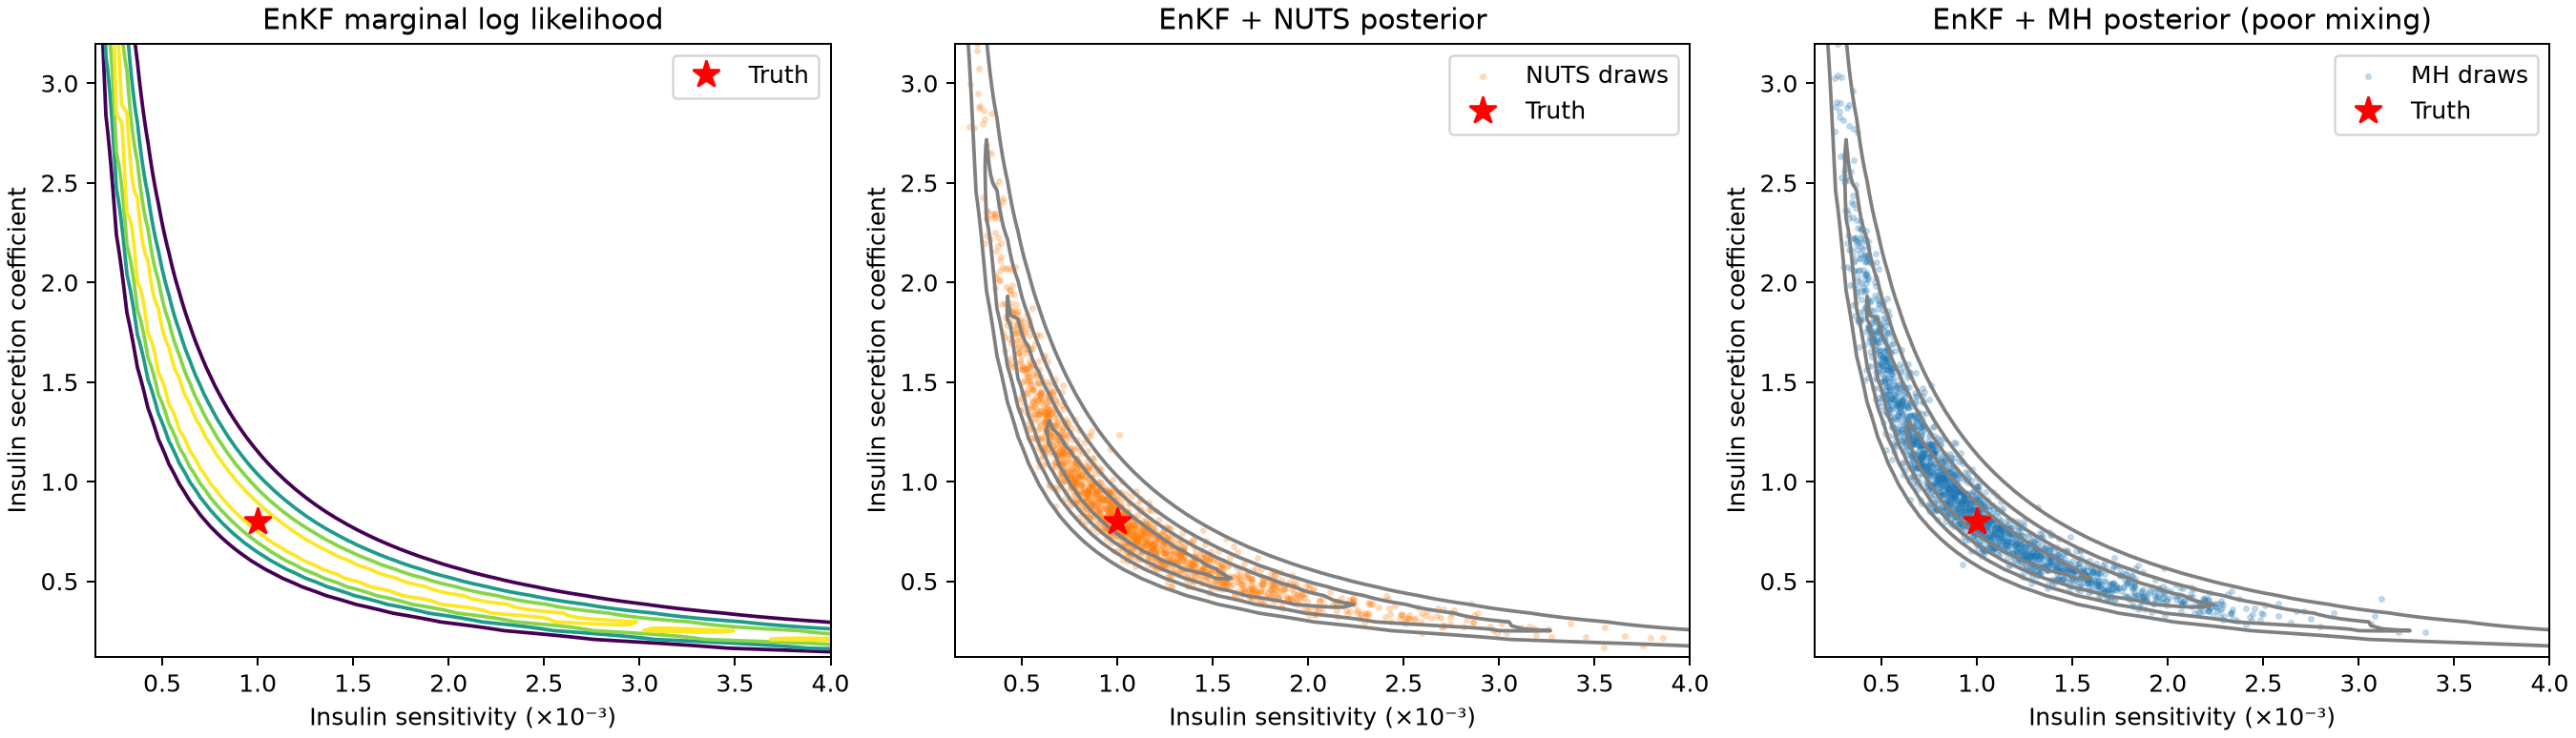

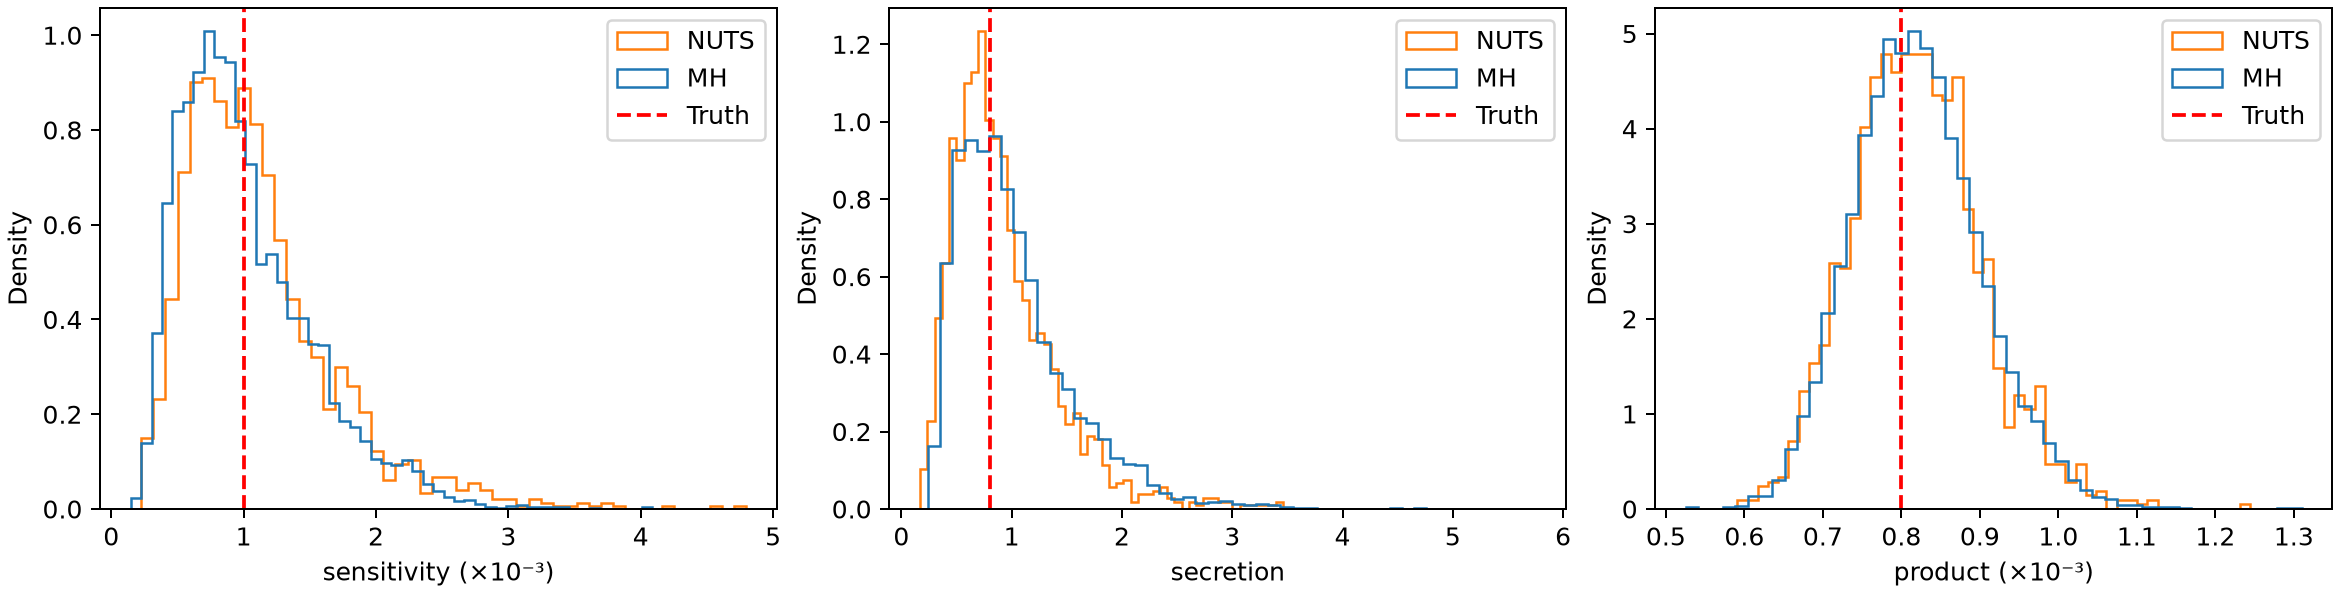

In [8]:
s_axis = np.linspace(0.00015, 0.004, 71)
b_axis = np.linspace(0.12, 3.2, 71)
aa, bb = np.meshgrid(s_axis, b_axis, indexing="ij")
points = jnp.asarray(np.stack([aa.ravel(), bb.ravel()], axis=1))
ll_grid = np.asarray(
    jax.jit(lambda p: jax.lax.map(loglik, p, batch_size=8))(points)
).reshape(aa.shape)
assert np.isfinite(ll_grid).all()
prior_grid = np.asarray(
    dist.LogNormal(jnp.log(TRUE["sensitivity"]), 0.7).log_prob(aa)
    + dist.LogNormal(jnp.log(TRUE["secretion"]), 0.7).log_prob(bb)
)
posterior_grid = ll_grid + prior_grid
np.savez_compressed(
    OUT / "grid.npz",
    sensitivity_axis=s_axis,
    secretion_axis=b_axis,
    loglik=ll_grid,
    logposterior=posterior_grid,
)
fig, axs = plt.subplots(1, 3, figsize=(15, 4.3), constrained_layout=True)
levels = [-6, -3, -1.5, -0.5]
axs[0].contour(
    aa * 1000, bb, ll_grid - ll_grid.max(), levels=levels, linestyles="solid"
)
axs[0].set_title("EnKF marginal log likelihood")
for ax, method, color in zip(axs[1:], ["NUTS", "MH"], ["tab:orange", "tab:blue"]):
    ax.contour(
        aa * 1000,
        bb,
        posterior_grid - posterior_grid.max(),
        levels=levels,
        colors="gray",
        linestyles="solid",
    )
    d = samples[method]
    # Subsample only the display, never the diagnostic calculation.
    stride = max(1, d["sensitivity"].size // 2000)
    ax.scatter(
        d["sensitivity"].ravel()[::stride] * 1000,
        d["secretion"].ravel()[::stride],
        s=4,
        alpha=0.2,
        color=color,
        label=f"{method} draws",
    )
    ax.set_title(
        f"EnKF + {method} posterior"
        + (
            " (poor mixing)"
            if method == "MH"
            and max(all_stats[method][k]["r_hat"] for k in NAMES) > 1.01
            else ""
        )
    )
for ax in axs:
    ax.plot(TRUE["sensitivity"] * 1000, TRUE["secretion"], "r*", ms=12, label="Truth")
    ax.set(
        xlabel="Insulin sensitivity (×10⁻³)",
        ylabel="Insulin secretion coefficient",
        xlim=(s_axis[0] * 1000, s_axis[-1] * 1000),
        ylim=(b_axis[0], b_axis[-1]),
    )
    ax.legend()
fig.savefig(OUT / "posteriors.png", dpi=180)
plt.show()

fig, axs = plt.subplots(1, 3, figsize=(13, 3.3), constrained_layout=True)
for ax, parameter, scale in zip(axs, [*NAMES, "product"], [1000.0, 1.0, 1000.0]):
    for method, color in [("NUTS", "tab:orange"), ("MH", "tab:blue")]:
        d = with_product[method][parameter].ravel() * scale
        ax.hist(d, bins=50, density=True, histtype="step", color=color, label=method)
    truth = TRUE.get(parameter, TRUE["sensitivity"] * TRUE["secretion"])
    ax.axvline(truth * scale, color="red", linestyle="--", label="Truth")
    ax.set(xlabel=parameter + (" (×10⁻³)" if scale == 1000 else ""), ylabel="Density")
    ax.legend()
fig.savefig(OUT / "marginals.png", dpi=180)
plt.show()

## Chain traces, autocorrelation, and efficiency

Trace plots retain both chains, and autocorrelation averages the two chain ACFs. Different x-axis lengths reflect the actual retained sample budgets. MH acceptance is per-coordinate and NUTS acceptance is a trajectory statistic; they are not directly comparable measures of efficiency.

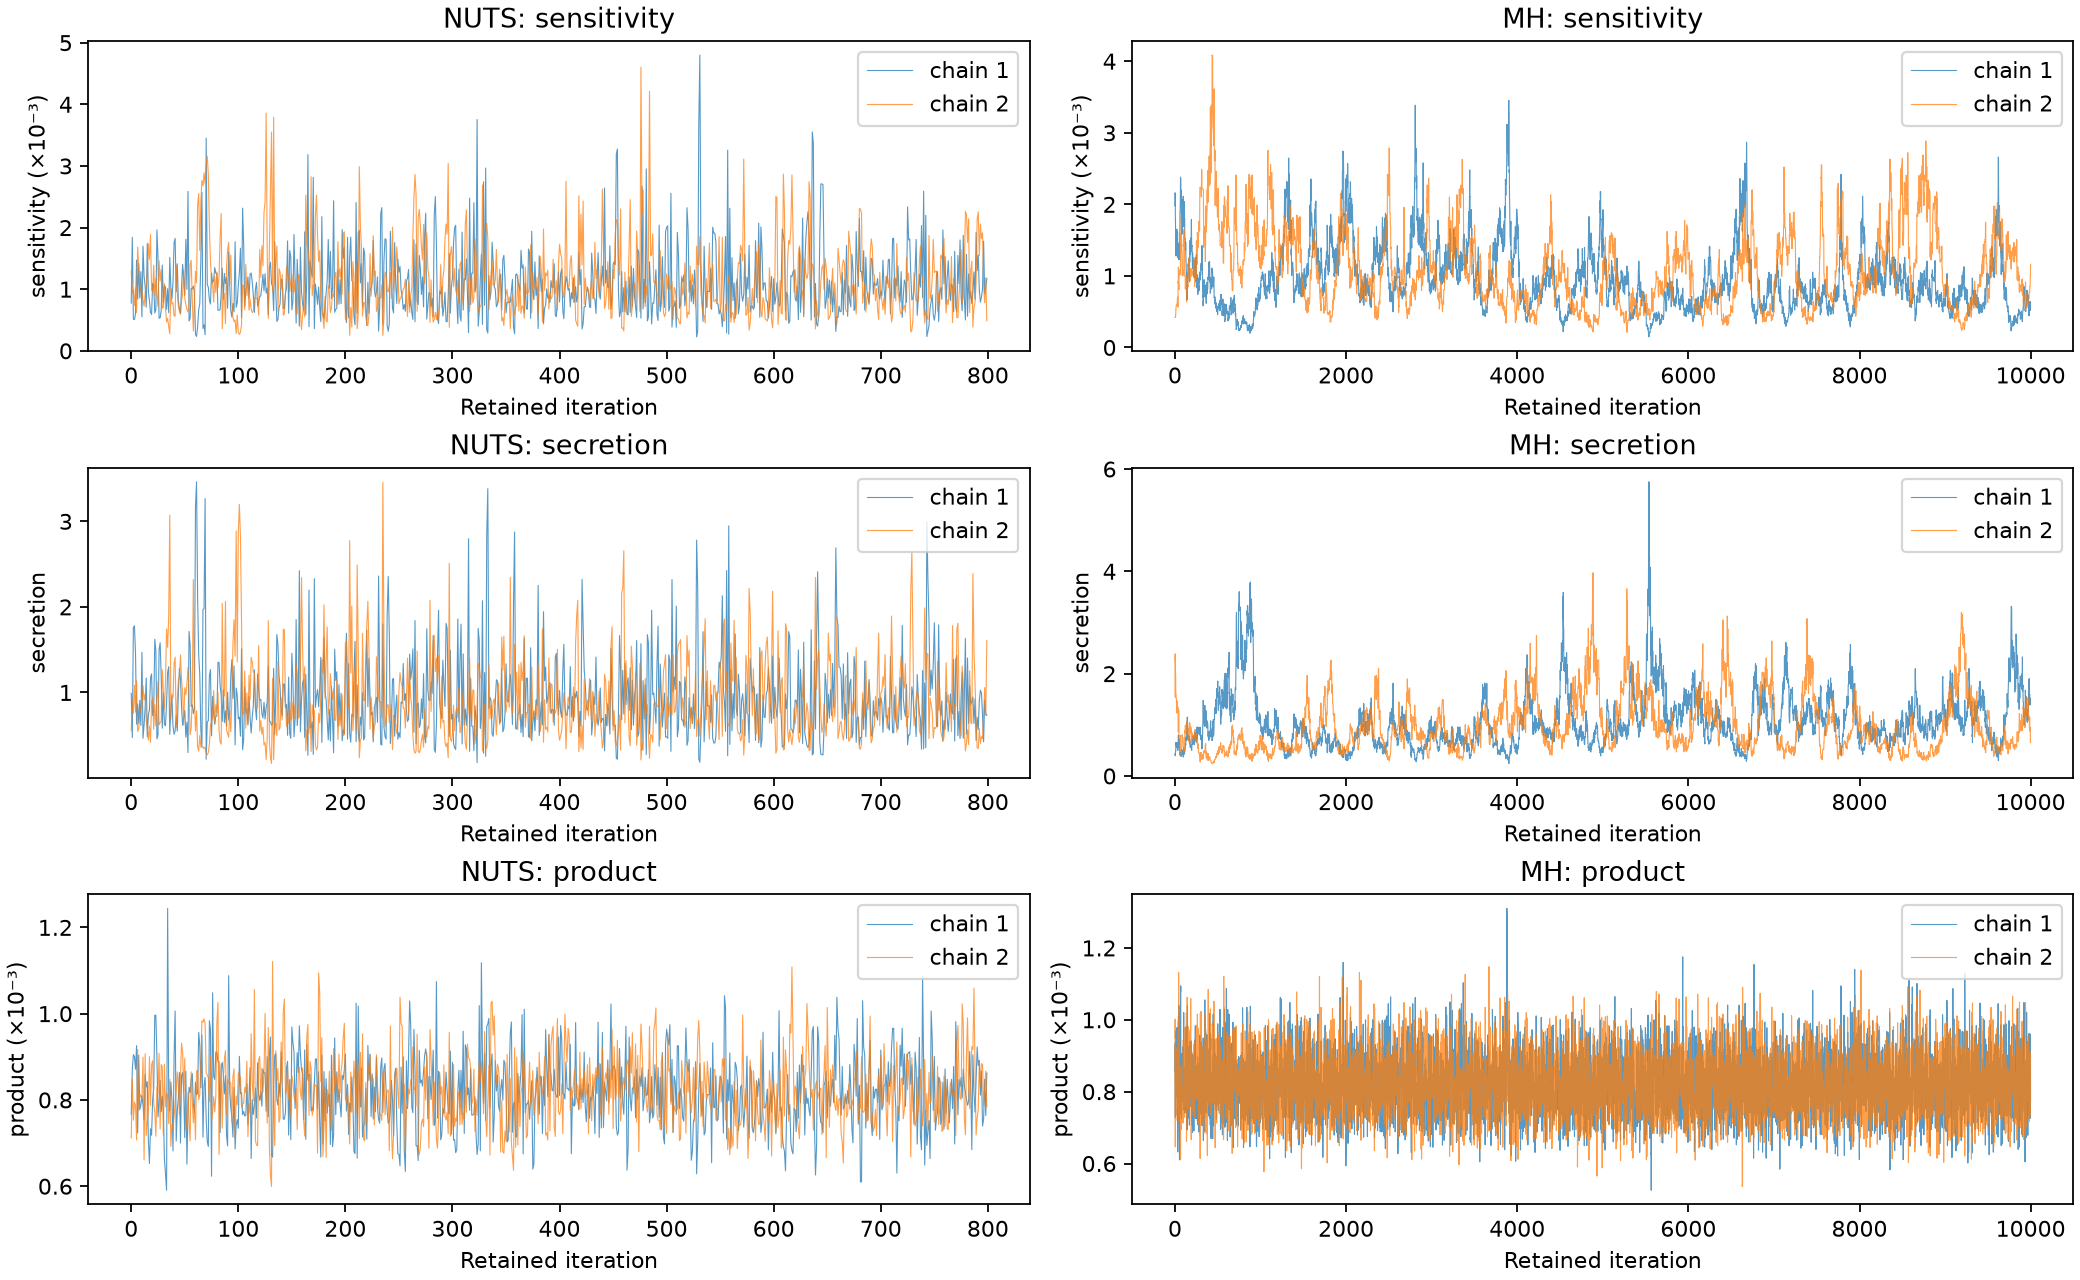

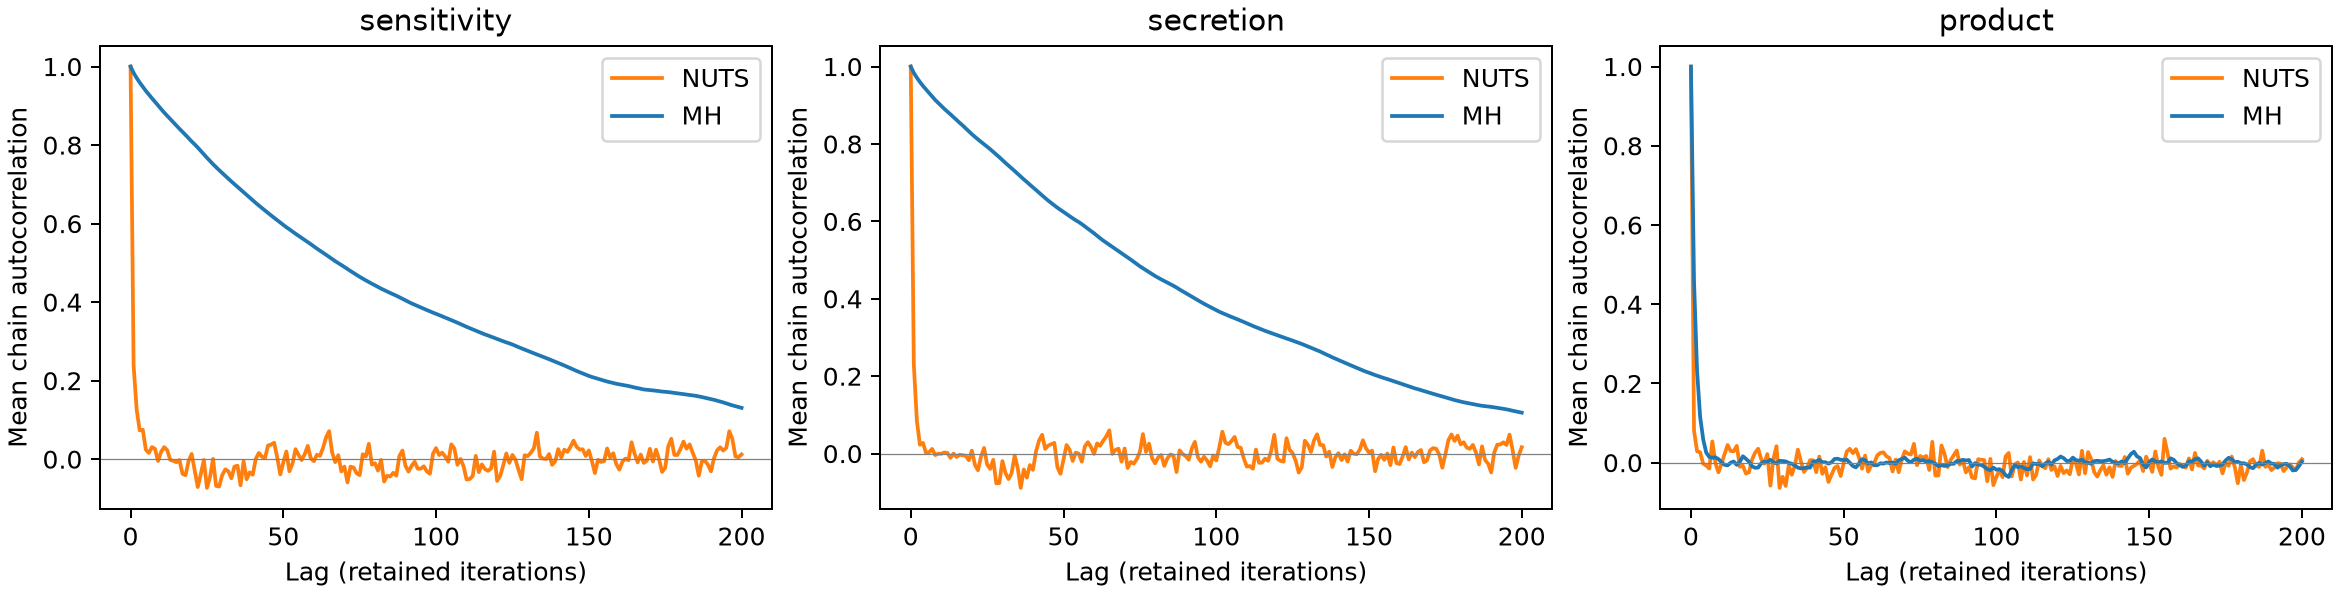

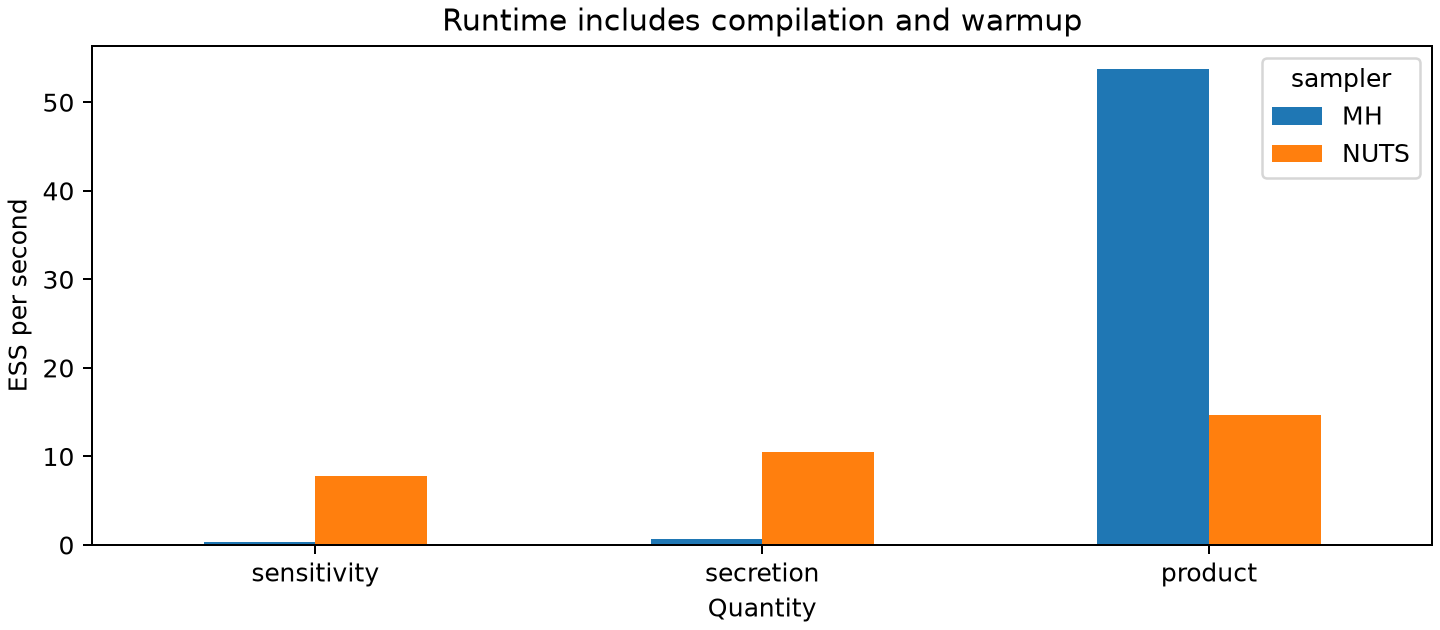

Posterior means versus the finite-grid reference (MCSE is an estimate):


,sampler,parameter,sample mean,grid mean,estimated mean MCSE,difference / MCSE
0,NUTS,sensitivity,0.001122,0.001115,0.000022,0.300287
1,NUTS,secretion,0.925007,0.923946,0.016028,0.066211
2,MH,sensitivity,0.001012,0.001115,0.000071,-1.439908
3,MH,secretion,1.021675,0.923946,0.057253,1.706975


Artifacts saved to /Users/levinema/Projects/research/_dynestyx/examples/ogtt_sde/results/sampler_comparison


In [9]:
fig, axs = plt.subplots(3, 2, figsize=(13, 8), constrained_layout=True)
for col, method in enumerate(["NUTS", "MH"]):
    for row, parameter in enumerate([*NAMES, "product"]):
        scale = 1000 if parameter != "secretion" else 1
        for chain, d in enumerate(with_product[method][parameter]):
            axs[row, col].plot(
                d * scale, lw=0.5, alpha=0.75, label=f"chain {chain + 1}"
            )
        axs[row, col].set(
            xlabel="Retained iteration",
            ylabel=parameter + (" (×10⁻³)" if scale == 1000 else ""),
            title=f"{method}: {parameter}",
        )
        axs[row, col].legend()
fig.savefig(OUT / "traces.png", dpi=160)
plt.show()

fig, axs = plt.subplots(1, 3, figsize=(13, 3.3), constrained_layout=True)
for ax, parameter in zip(axs, [*NAMES, "product"]):
    for method, color in [("NUTS", "tab:orange"), ("MH", "tab:blue")]:
        acf = np.asarray(
            autocorrelation(jnp.asarray(with_product[method][parameter]), axis=1)
        ).mean(axis=0)
        stop = min(201, len(acf))
        ax.plot(np.arange(stop), acf[:stop], label=method, color=color)
    ax.set(
        xlabel="Lag (retained iterations)",
        ylabel="Mean chain autocorrelation",
        title=parameter,
    )
    ax.axhline(0, color="gray", lw=0.5)
    ax.legend()
fig.savefig(OUT / "autocorrelation.png", dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(8, 3.5), constrained_layout=True)
efficiency = comparison["ESS/s"].unstack("sampler").reindex([*NAMES, "product"])
efficiency.plot.bar(ax=ax, color={"NUTS": "tab:orange", "MH": "tab:blue"}, rot=0)
ax.set(
    ylabel="ESS per second",
    xlabel="Quantity",
    title="Runtime includes compilation and warmup",
)
fig.savefig(OUT / "efficiency.png", dpi=180)
plt.show()

weights = np.exp(posterior_grid - logsumexp(posterior_grid))
grid_means = np.array([(weights * aa).sum(), (weights * bb).sum()])
checks = []
for method in samples:
    for i, parameter in enumerate(NAMES):
        d = all_stats[method][parameter]
        mcse = float(d["std"]) / np.sqrt(float(d["n_eff"]))
        checks.append(
            {
                "sampler": method,
                "parameter": parameter,
                "sample mean": float(d["mean"]),
                "grid mean": grid_means[i],
                "estimated mean MCSE": mcse,
                "difference / MCSE": (float(d["mean"]) - grid_means[i]) / mcse,
            }
        )
print("Posterior means versus the finite-grid reference (MCSE is an estimate):")
display(pd.DataFrame(checks))
print("Artifacts saved to", OUT)

The posterior contour grid has finite limits and finite resolution, so grid means are approximate references. The 20-member EnKF target remains an approximation to the SDE posterior. The earlier SDE example checked its geometry against an independent 256-member grid and likelihood ratios against 1,024 members; this notebook concentrates on comparing samplers against the **identical** target. ESS estimates and R-hat should be interpreted alongside the trace and autocorrelation plots. MH's divergence diagnostic is not applicable, so its acceptance rates and chain mixing are shown instead.